# Initial Data Exploration – UK House Price Index (Nov 2025)

Goal:
- Understand the structure of the UKHPI dataset
- Identify available metrics and time coverage
- Spot data quality issues (missing values, weird columns, formats)
- Brainstorm possible analysis questions

Notes:
- This notebook is exploratory and may contain trial-and-error code
- Insights here will inform later analysis notebooks


In [1]:
import pandas as pd

In [2]:
df_average_prices = pd.read_csv('/home/prem/UK Home Price Analysis/Average Price Analysis November 2025/Data/Raw/Average-prices-2025-11.csv')

In [3]:
df_average_prices


,Date,Region_Name,Area_Code,Average_Price,Monthly_Change,Annual_Change,Average_Price_SA
0,1968-04-01,Northern Ireland,N92000002,3465,NaN,NaN,NaN
1,1968-04-01,England,E92000001,3218,NaN,NaN,NaN
2,1968-04-01,Wales,W92000004,2732,NaN,NaN,NaN
3,1968-04-01,Scotland,S92000003,2738,NaN,NaN,NaN
4,1968-04-01,London,E12000007,4730,NaN,NaN,NaN
...,...,...,...,...,...,...,...
148675,2025-11-01,Wokingham,E06000041,501435,-1.8,3.0,NaN
148676,2025-11-01,Milton Keynes,E06000042,327312,0.3,1.1,NaN
148677,2025-11-01,England and Wales,K04000001,287528,0.3,2.1,285532.0
148678,2025-11-01,Great Britain,K03000001,273695,0.3,2.4,271727.0


In [4]:
df_average_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148680 entries, 0 to 148679
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              148680 non-null  object 
 1   Region_Name       148680 non-null  object 
 2   Area_Code         148680 non-null  object 
 3   Average_Price     148680 non-null  int64  
 4   Monthly_Change    148227 non-null  float64
 5   Annual_Change     143820 non-null  float64
 6   Average_Price_SA  5229 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 7.9+ MB


In [5]:
df_average_prices['Average_Price_SA'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 148680 entries, 0 to 148679
Series name: Average_Price_SA
Non-Null Count  Dtype  
--------------  -----  
5229 non-null   float64
dtypes: float64(1)
memory usage: 1.1 MB


In [6]:
df_average_prices.isna().sum()

Date                     0
Region_Name              0
Area_Code                0
Average_Price            0
Monthly_Change         453
Annual_Change         4860
Average_Price_SA    143451
dtype: int64

In [7]:
df_average_prices['Date'] = pd.to_datetime(df_average_prices['Date'])
df_average_prices

,Date,Region_Name,Area_Code,Average_Price,Monthly_Change,Annual_Change,Average_Price_SA
0,1968-04-01,Northern Ireland,N92000002,3465,NaN,NaN,NaN
1,1968-04-01,England,E92000001,3218,NaN,NaN,NaN
2,1968-04-01,Wales,W92000004,2732,NaN,NaN,NaN
3,1968-04-01,Scotland,S92000003,2738,NaN,NaN,NaN
4,1968-04-01,London,E12000007,4730,NaN,NaN,NaN
...,...,...,...,...,...,...,...
148675,2025-11-01,Wokingham,E06000041,501435,-1.8,3.0,NaN
148676,2025-11-01,Milton Keynes,E06000042,327312,0.3,1.1,NaN
148677,2025-11-01,England and Wales,K04000001,287528,0.3,2.1,285532.0
148678,2025-11-01,Great Britain,K03000001,273695,0.3,2.4,271727.0


In [8]:
df_date_2025_11 = df_average_prices[df_average_prices['Date'] == '2025-11-01']

In [9]:
df_date_2025_11
la_prefixes = ('E06','E07','E08','E09','W06','S12','N09')

df_la = df_date_2025_11[df_date_2025_11['Area_Code'].str.startswith(la_prefixes)].copy()


In [10]:
df_pivot_month = df_la.pivot_table(
    index = 'Region_Name',
    values = 'Average_Price'
)
df_pivot_month.sort_values('Average_Price', ascending = False, inplace = True)
df_date_2025_11[df_date_2025_11['Region_Name'] == 'Inner London']

,Date,Region_Name,Area_Code,Average_Price,Monthly_Change,Annual_Change,Average_Price_SA
148280,2025-11-01,Inner London,E13000001,631062,-1.0,-4.6,NaN


In [11]:
df_top_regions = df_pivot_month.head(10)

In [12]:
df_top_regions

,Average_Price
Region_Name,
Kensington and Chelsea,1184811.0
City of Westminster,866170.0
Camden,800930.0
Elmbridge,769277.0
Richmond upon Thames,767961.0
Hammersmith and Fulham,738593.0
Wandsworth,688570.0
Islington,685840.0
City of London,662392.0


<Axes: title={'center': 'Average land price by region for 2025-11-01(Top 10 expensive regions)'}, xlabel='Region', ylabel='Average_Price'>

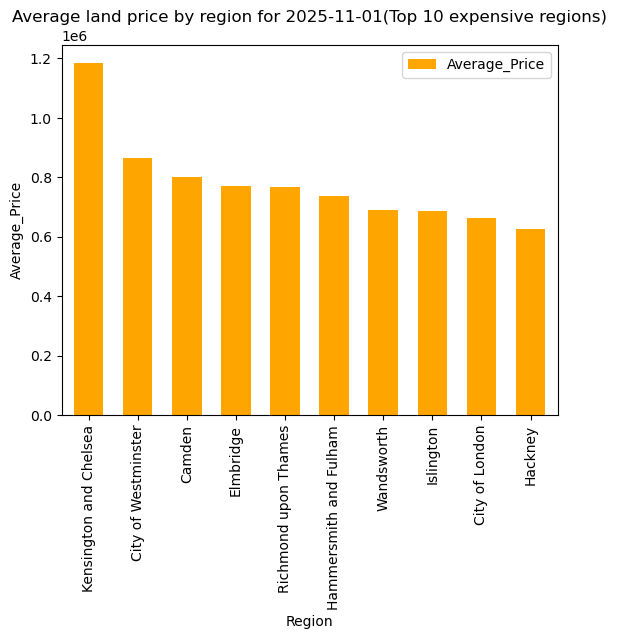

In [13]:
df_top_regions.plot(kind = 'bar',
                   xlabel = 'Region',
                   ylabel = 'Average_Price',
                   title = 'Average land price by region for 2025-11-01(Top 10 expensive regions)',
                  width = 0.6,
                   color = 'orange'
                  )

In [14]:
df_bottom_regions = df_pivot_month.tail(10).sort_values('Average_Price')
df_bottom_regions

,Average_Price
Region_Name,
Inverclyde,110448.0
West Dunbartonshire,125293.0
Burnley,128106.0
City of Kingston upon Hull,130982.0
Hyndburn,132148.0
Hartlepool,134091.0
East Ayrshire,135014.0
North Ayrshire,135751.0
City of Aberdeen,136227.0


<Axes: title={'center': 'Average land price by region for 2025-11-01 (Top 10 least expensive regions)'}, xlabel='Region', ylabel='Average_Price'>

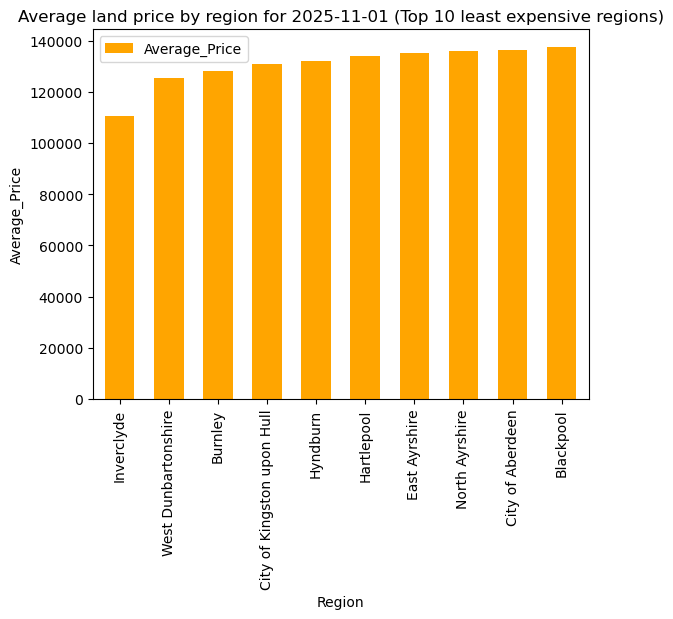

In [15]:
df_bottom_regions.plot(kind = 'bar',
                   xlabel = 'Region',
                   ylabel = 'Average_Price',
                   title = 'Average land price by region for 2025-11-01 (Top 10 least expensive regions)',
                  width = 0.6,
                   color = 'orange'
                  )

In [16]:
df_date_2025_11

,Date,Region_Name,Area_Code,Average_Price,Monthly_Change,Annual_Change,Average_Price_SA
148275,2025-11-01,Scotland,S92000003,193114,0.3,4.5,191557.0
148276,2025-11-01,Northern Ireland,N92000002,193247,4.3,7.1,NaN
148277,2025-11-01,Wales,W92000004,208935,-0.6,0.7,206112.0
148278,2025-11-01,England,E92000001,293131,0.4,2.2,291280.0
148279,2025-11-01,Outer London,E13000002,507843,-0.2,0.1,NaN
...,...,...,...,...,...,...,...
148675,2025-11-01,Wokingham,E06000041,501435,-1.8,3.0,NaN
148676,2025-11-01,Milton Keynes,E06000042,327312,0.3,1.1,NaN
148677,2025-11-01,England and Wales,K04000001,287528,0.3,2.1,285532.0
148678,2025-11-01,Great Britain,K03000001,273695,0.3,2.4,271727.0


In [17]:
df_growth = df_la.dropna(subset = ['Annual_Change'])
df_growth = df_growth.pivot_table(index = 'Region_Name', values = ['Annual_Change'])

In [18]:
df_top_growth = df_growth.sort_values(
    'Annual_Change',
    ascending = False
).head(10)


In [19]:
df_bottom_growth = df_growth.sort_values(
    'Annual_Change',
    ascending = True
).head(10)

<Axes: title={'center': 'Annual Change in average price from 2024-11-01 to 2025-11-01'}, xlabel='Region', ylabel='Annual Change(%)'>

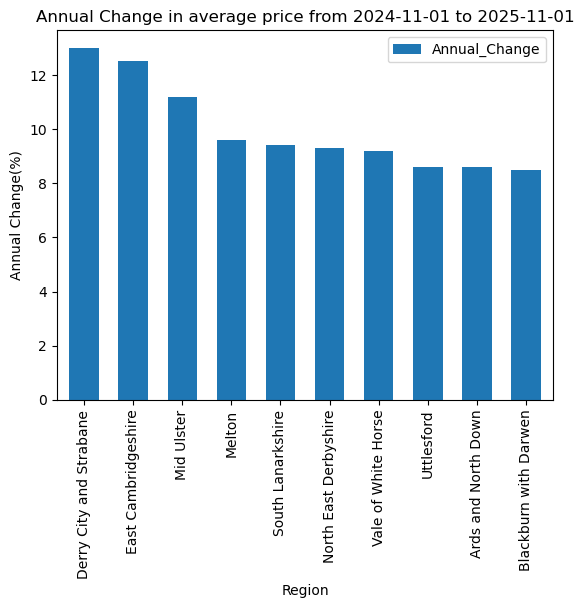

In [20]:
df_top_growth.plot(kind = 'bar',
                   xlabel = 'Region',
                   ylabel = 'Annual Change(%)',
                   title = 'Annual Change in average price from 2024-11-01 to 2025-11-01',
                  width = 0.6,
                   # color = 'orange'
                  )

<Axes: title={'center': 'Annual Change in average price from 2024-11-01 to 2025-11-01'}, xlabel='Region', ylabel='Annual Change(%)'>

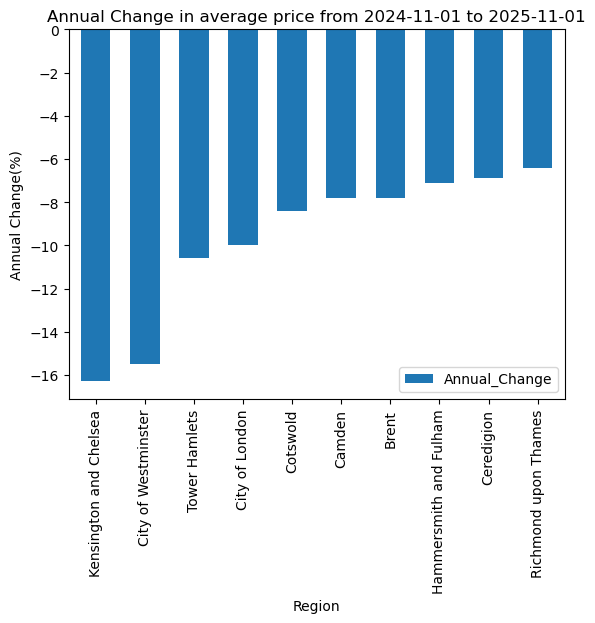

In [21]:
df_bottom_growth.plot(kind = 'bar',
                   xlabel = 'Region',
                   ylabel = 'Annual Change(%)',
                   title = 'Annual Change in average price from 2024-11-01 to 2025-11-01',
                  width = 0.6,
                   # color = 'orange'
                  )

In [22]:
df_growth['Annual_Change'].mean()

np.float64(1.8763888888888889)

<Axes: title={'center': 'Average land price by region for 2025-11-01(Top 10 expensive regions)'}, xlabel='Region', ylabel='Average_Price'>

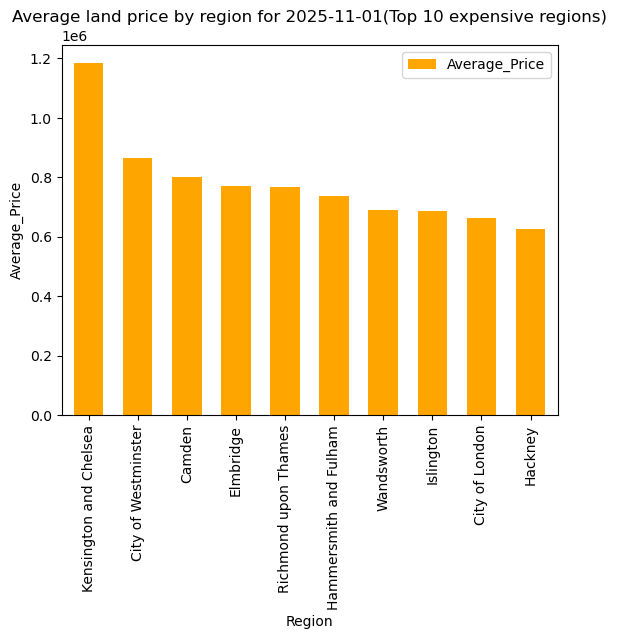

In [56]:
df_top_regions.plot(kind = 'bar',
                   xlabel = 'Region',
                   ylabel = 'Average_Price',
                   title = 'Average land price by region for 2025-11-01(Top 10 expensive regions)',
                  width = 0.6,
                   color = 'orange'
                  )

In [24]:
# filtering out top five regions in terms of average price
df_top_5 = df_top_regions.head()
df_top_5

,Average_Price
Region_Name,
Kensington and Chelsea,1184811.0
City of Westminster,866170.0
Camden,800930.0
Elmbridge,769277.0
Richmond upon Thames,767961.0


In [60]:
exp_places = ['Kensington and Chelsea', 'City of Westminster', 'Camden', 'Elmbridge', 'Richmond upon Thames', 'Hammersmith and Fulham', 'Wandswort', 'Islington',
             'City of London', 'Hackney']
dates = pd.to_datetime(['2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01', 
         '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
        '2025-09-01', '2025-10-01', '2025-11-01'])
filtered_df = df_average_prices[
    (df_average_prices['Region_Name'].isin(exp_places)) & 
    (df_average_prices['Date'].isin(dates))
].copy()

In [61]:
filtered_df

,Date,Region_Name,Area_Code,Average_Price,Monthly_Change,Annual_Change,Average_Price_SA
143491,2024-11-01,City of London,E09000001,735940,-0.8,-13.7,NaN
143498,2024-11-01,Richmond upon Thames,E09000027,820875,0.9,5.0,NaN
143504,2024-11-01,City of Westminster,E09000033,1025153,-3.4,-3.3,NaN
143508,2024-11-01,Islington,E09000019,689644,-0.8,-2.0,NaN
143509,2024-11-01,Kensington and Chelsea,E09000020,1414918,-1.1,-3.0,NaN
...,...,...,...,...,...,...,...
148379,2025-11-01,Camden,E09000007,800930,-2.5,-7.8,NaN
148384,2025-11-01,Hackney,E09000012,625292,0.5,2.0,NaN
148385,2025-11-01,Hammersmith and Fulham,E09000013,738593,0.9,-7.1,NaN
148391,2025-11-01,Islington,E09000019,685840,-0.6,-0.6,NaN


In [62]:
pivot = filtered_df.pivot_table(index = 'Region_Name', values = 'Average_Price', columns = 'Date')

NameError: name 'ax' is not defined

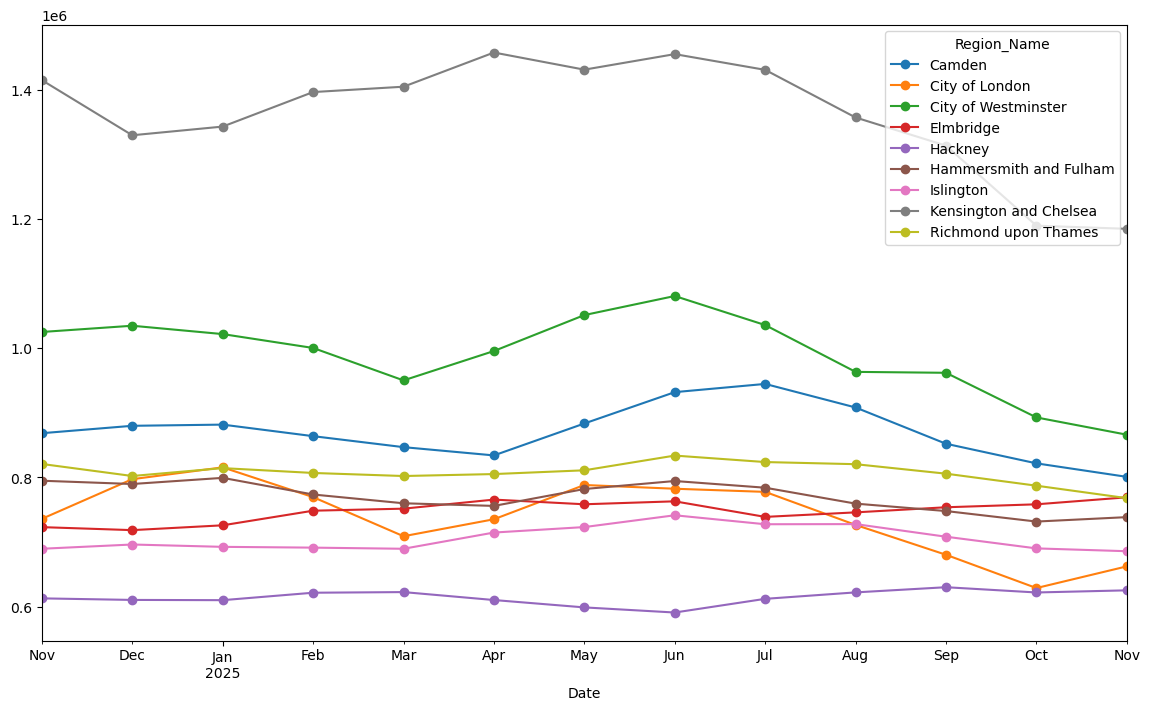

In [63]:
x = pivot.T.plot(kind='line', figsize=(14, 8), marker='o')

# Enhance the plot with labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_title('Price Trends by Region')
ax.legend(title='Region')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure layout fits well
plt.tight_layout()

# Show the plot
plt.show()

In [64]:
pivot

Date,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01
Region_Name,,,,,,,,,,,,,
Camden,868481.0,879944.0,881785.0,863911.0,846904.0,834111.0,883523.0,932037.0,944759.0,908297.0,852156.0,821820.0,800930.0
City of London,735940.0,797319.0,815621.0,769559.0,709035.0,735310.0,788306.0,782548.0,777679.0,726547.0,680327.0,628829.0,662392.0
City of Westminster,1025153.0,1034803.0,1021893.0,1000415.0,950218.0,995677.0,1051320.0,1080820.0,1035853.0,963402.0,961982.0,892888.0,866170.0
Elmbridge,723118.0,718468.0,725931.0,748542.0,751697.0,765723.0,758490.0,763058.0,738965.0,745965.0,753862.0,758431.0,769277.0
Hackney,612864.0,610454.0,610074.0,621589.0,622578.0,610289.0,598878.0,590955.0,612134.0,622110.0,630121.0,621981.0,625292.0
Hammersmith and Fulham,794934.0,789873.0,799364.0,773625.0,760038.0,755966.0,782103.0,794494.0,784122.0,759501.0,748010.0,731743.0,738593.0
Islington,689644.0,696225.0,692596.0,691385.0,689619.0,714733.0,723205.0,741470.0,727589.0,727798.0,708278.0,690203.0,685840.0
Kensington and Chelsea,1414918.0,1329608.0,1343046.0,1396472.0,1404765.0,1457670.0,1431144.0,1455187.0,1430837.0,1357118.0,1313521.0,1189651.0,1184811.0
Richmond upon Thames,820875.0,802247.0,814455.0,806957.0,802222.0,805248.0,811066.0,833855.0,823839.0,820536.0,805849.0,787251.0,767961.0


In [65]:
filtered_df[filtered_df['Region_Name'] == 'Camden']['Average_Price'].mean()

np.float64(870666.0)

In [66]:
df_price_change = (
    filtered_df
    .sort_values(['Region_Name', 'Date'])
    .groupby('Region_Name')
    .agg(
        start_price = ('Average_Price', 'first'),
        end_price = ('Average_Price', 'last')
    )
)

In [67]:
df_price_change['pct_change'] = ((df_price_change['end_price'] - df_price_change['start_price'])/ df_price_change['start_price'] *100).round(2)

In [68]:
df_price_change.reset_index()

,Region_Name,start_price,end_price,pct_change
0,Camden,868481,800930,-7.78
1,City of London,735940,662392,-9.99
2,City of Westminster,1025153,866170,-15.51
3,Elmbridge,723118,769277,6.38
4,Hackney,612864,625292,2.03
5,Hammersmith and Fulham,794934,738593,-7.09
6,Islington,689644,685840,-0.55
7,Kensington and Chelsea,1414918,1184811,-16.26
8,Richmond upon Thames,820875,767961,-6.45
